# EDA

In [79]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from skimage.measure import label, regionprops
import seaborn as sns


sns.set(style='whitegrid')

In [80]:
BASE_DIR = "/kaggle/input/recodai-luc-scientific-image-forgery-detection"

In [81]:
train_image_paths = sorted(glob(os.path.join(BASE_DIR, "train_images", "*", "*.png")))
train_mask_paths = sorted(glob(os.path.join(BASE_DIR, "train_masks", "*.npy")))

In [82]:
print(f"This is a size of train image {len(train_image_paths)} and this is a size mask, {len(train_mask_paths)}")

This is a size of train image 5128 and this is a size mask, 2751


In [83]:
def get_id(path):
    return os.path.splitext(os.path.basename(path))[0]

mask_map = {get_id(p): p for p in train_mask_paths}


In [84]:
pairs = []

for img_path in train_image_paths:
    cid = get_id(img_path)

    if cid in mask_map:
        mask_path = mask_map[cid]
        has_forgery = True
    else:
        mask_path = None   # authentic
        has_forgery = False

    pairs.append({
        "img_path": img_path,
        "mask_path": mask_path,
        "has_forgery": has_forgery
    })


print(f"Total images: {len(pairs)}")
print(f"Total forged images: {sum(p['has_forgery'] for p in pairs)}")
print(f"Total authentic images: {len(pairs) - sum(p['has_forgery'] for p in pairs)}")


Total images: 5128
Total forged images: 5128
Total authentic images: 0


In [94]:
def load_mask(mask_path, img_shape):
    H, W = img_shape[:2]
    if H == 0 or W == 0:
        return np.zeros((0,0), dtype=np.uint8)

    if mask_path is None:
        return np.zeros((H, W), dtype=np.uint8)

    try:
        mask = np.load(mask_path)
    except:
        return np.zeros((H, W), dtype=np.uint8)

    if mask.size == 0:
        return np.zeros((H, W), dtype=np.uint8)

    # اگر mask یک بعدی است یا اندازه تطابق ندارد
    if mask.ndim == 1 or mask.size != H*W:
        mask = np.zeros((H, W), dtype=np.uint8)
    else:
        try:
            mask = mask.reshape((H, W))
        except:
            mask = np.zeros((H, W), dtype=np.uint8)

    # اطمینان از باینری بودن
    mask = (mask > 0).astype(np.uint8)
    return mask


In [92]:
pairs = []
for img_path in train_image_paths:
    cid = get_id(img_path)
    if cid in mask_map:
        mask_path = mask_map[cid]
        has_forgery = True
    else:
        mask_path = None
        has_forgery = False
    pairs.append({"img_path": img_path, "mask_path": mask_path, "has_forgery": has_forgery})


In [93]:
print(f"Total images: {len(pairs)}")
print(f"Total forged images: {sum(p['has_forgery'] for p in pairs)}")
print(f"Total authentic images: {len(pairs) - sum(p['has_forgery'] for p in pairs)}")

Total images: 5128
Total forged images: 5128
Total authentic images: 0


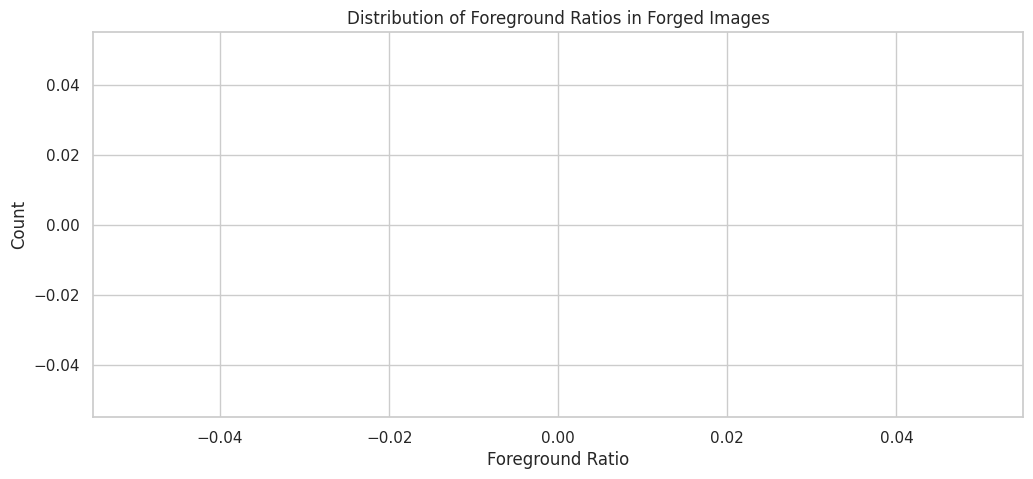

In [95]:
plt.figure(figsize=(12,5))
sns.histplot(fg_ratios, bins=50, kde=True)
plt.title("Distribution of Foreground Ratios in Forged Images")
plt.xlabel("Foreground Ratio")
plt.ylabel("Count")
plt.show()




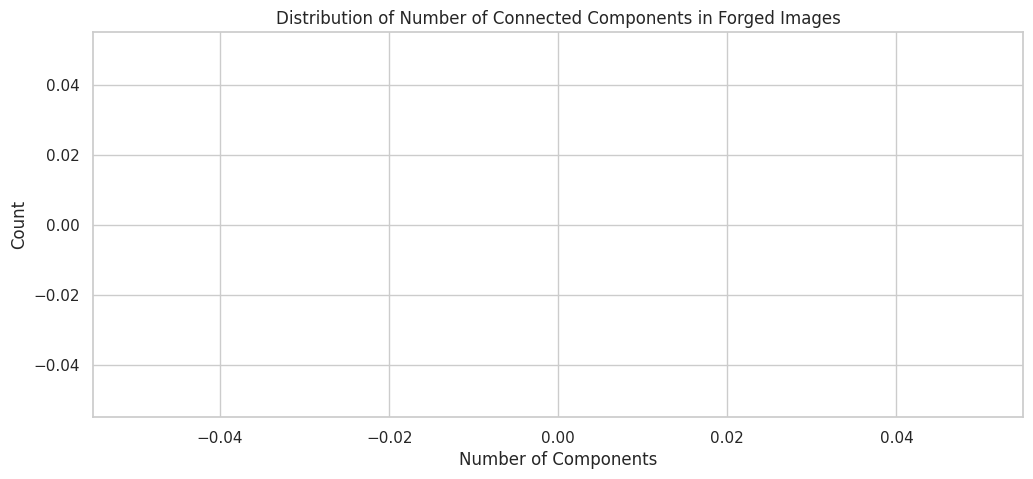

In [96]:
plt.figure(figsize=(12,5))
sns.histplot(n_components, bins=20, kde=True)
plt.title("Distribution of Number of Connected Components in Forged Images")
plt.xlabel("Number of Components")
plt.ylabel("Count")
plt.show()

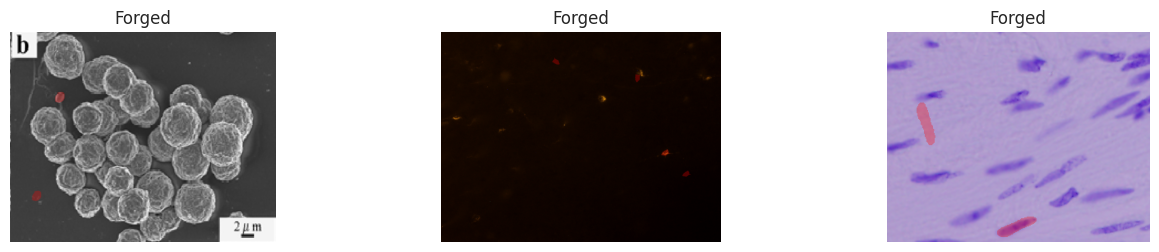

In [97]:
def show_samples(pairs, n=6):
    forged_samples = [p for p in pairs if p["has_forgery"]]
    authentic_samples = [p for p in pairs if not p["has_forgery"]]

    samples = forged_samples[:n//2] + authentic_samples[:n//2]

    plt.figure(figsize=(16,6))
    for i, p in enumerate(samples):
        img = cv2.imread(p["img_path"])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = load_mask(p["mask_path"], img.shape)

        img_to_show = img.copy()
        if p["has_forgery"]:
            overlay = img.copy()
            overlay[mask==1] = [255,0,0]  # red overlay
            img_to_show = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

        plt.subplot(2, n//2, i+1)
        plt.imshow(img_to_show)
        plt.axis("off")
        plt.title("Forged" if p["has_forgery"] else "Authentic")
    plt.show()

show_samples(pairs, n=6)

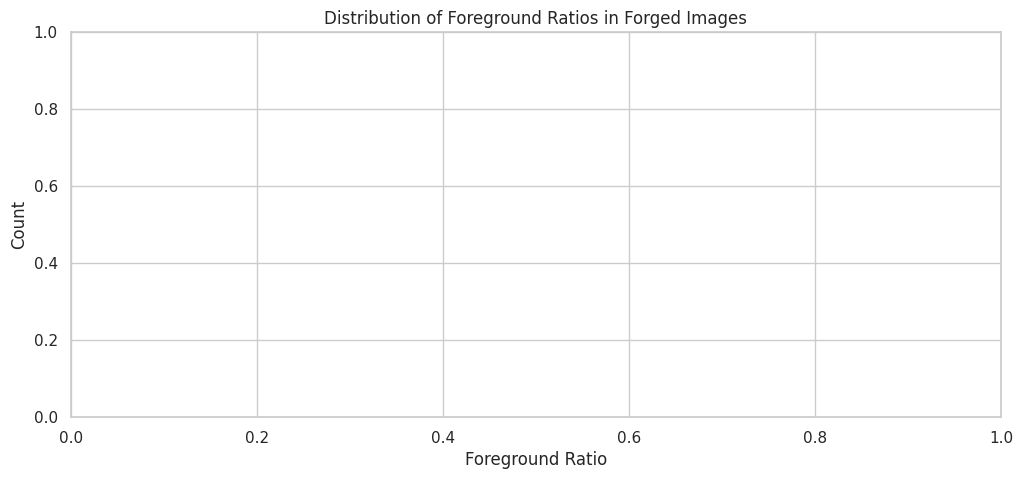

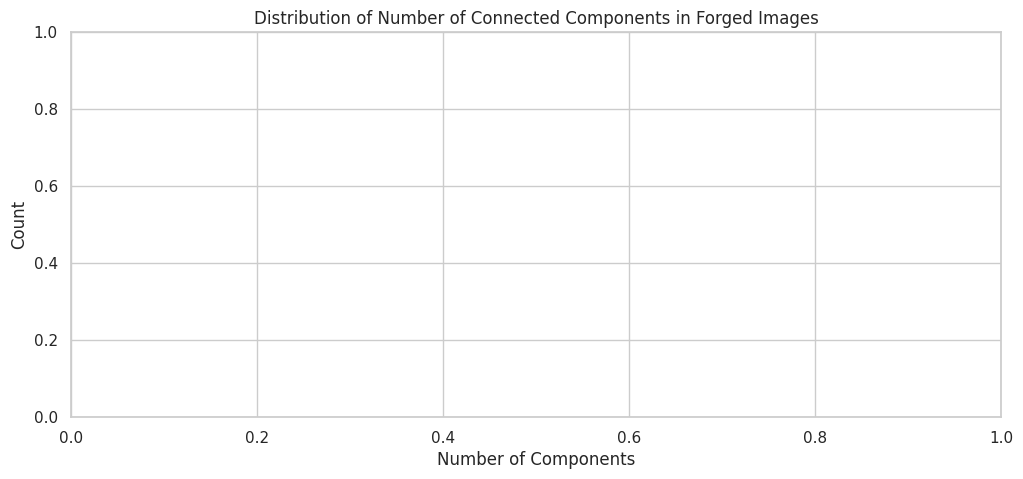

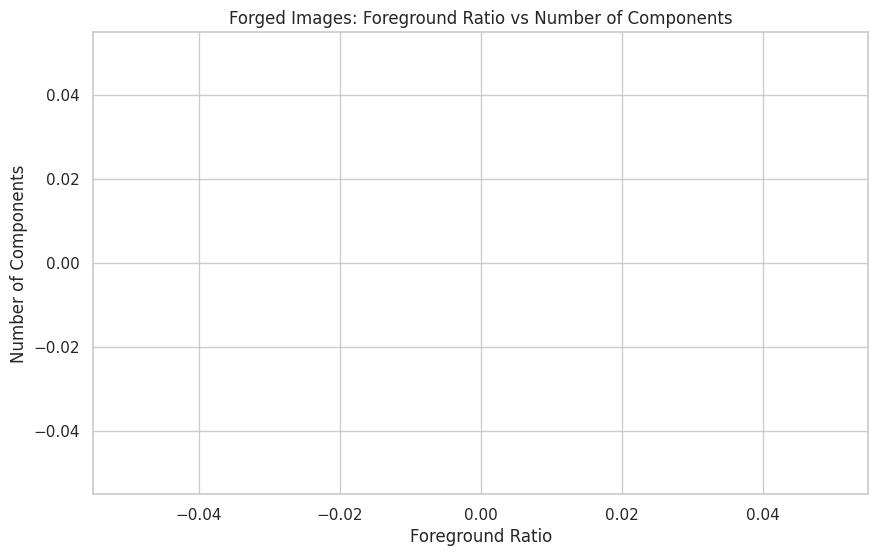

In [98]:
plt.figure(figsize=(12,5))
sns.histplot(fg_ratios, bins=50, kde=True, color='red')
plt.title("Distribution of Foreground Ratios in Forged Images")
plt.xlabel("Foreground Ratio")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(n_components, bins=20, kde=True, color='blue')
plt.title("Distribution of Number of Connected Components in Forged Images")
plt.xlabel("Number of Components")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(fg_ratios, n_components, alpha=0.6, c='purple')
plt.xlabel("Foreground Ratio")
plt.ylabel("Number of Components")
plt.title("Forged Images: Foreground Ratio vs Number of Components")
plt.show()